In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


# Cross-Country Climate Comparison - Africa (2015-2026)

## Overview
This notebook compares daily climate data across 5 African countries:
Ethiopia, Kenya, Sudan, Tanzania and Nigeria.

The goal is to identify which countries are most vulnerable to climate 
change and produce insights that can support Ethiopia's position at COP32.

In [2]:
# Load all cleaned datasets
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

# Combine all into one dataframe
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nCountries:", df["Country"].unique())

Combined dataset shape: (20540, 15)

Countries: ['Ethiopia' 'Kenya' 'Sudan' 'Tanzania' 'Nigeria']


## Data Loading
All 5 cleaned country datasets were combined into a single dataframe
containing 20540 daily observations across Ethiopia, Kenya, Sudan,
Tanzania and Nigeria from 2015 to 2026.

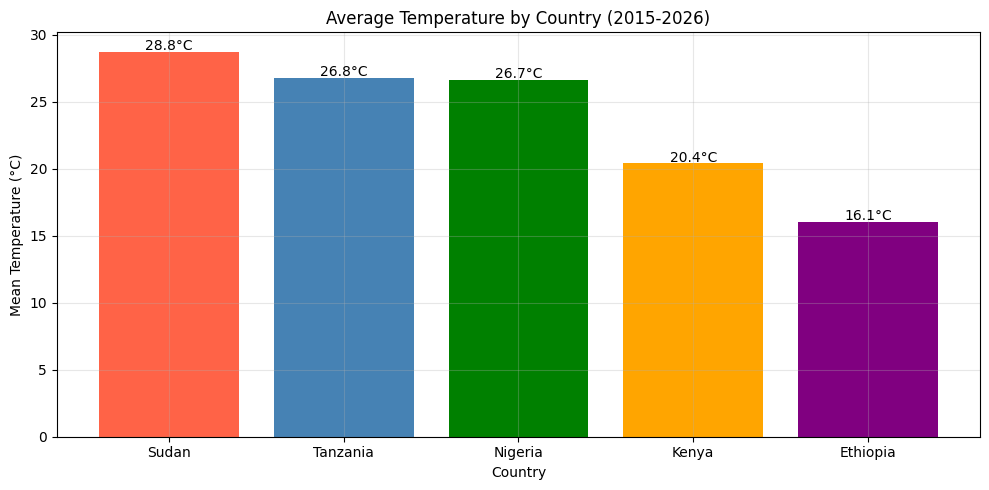

In [3]:
# Compare average temperature by country
avg_temp = df.groupby("Country")["T2M"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_temp.index, avg_temp.values, color=["tomato", "steelblue", "green", "orange", "purple"])
plt.title("Average Temperature by Country (2015-2026)")
plt.xlabel("Country")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, avg_temp.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f"{val:.1f}°C", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Average Temperature Comparison
Sudan is the hottest country with the highest mean temperature 
followed by Tanzania and Nigeria. Ethiopia is the coolest country 
due to its high altitude location in Addis Ababa.

Key finding: There is a large temperature gap between Sudan (desert) 
and Ethiopia (highland) showing how dramatically climate conditions 
differ across Africa even within the same region.

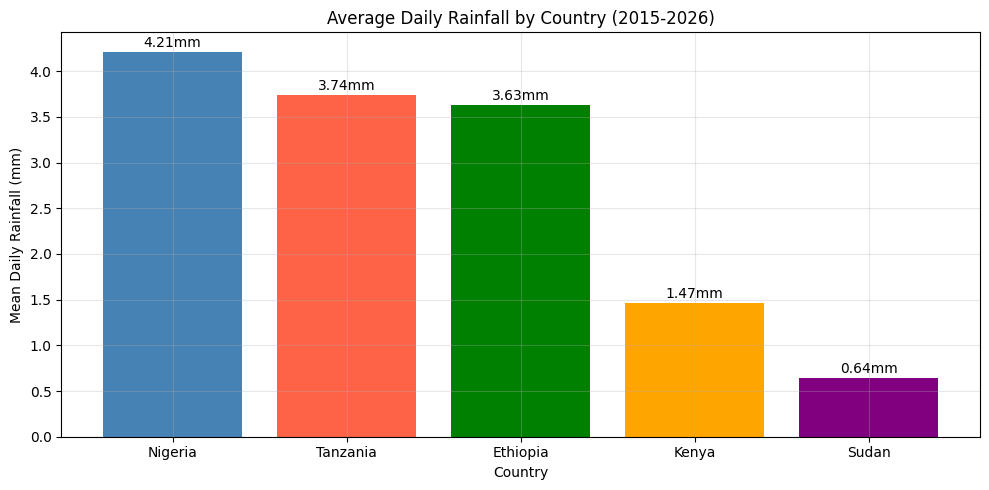

In [4]:
# Compare average rainfall by country
avg_rain = df.groupby("Country")["PRECTOTCORR"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_rain.index, avg_rain.values, color=["steelblue", "tomato", "green", "orange", "purple"])
plt.title("Average Daily Rainfall by Country (2015-2026)")
plt.xlabel("Country")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, avg_rain.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.2f}mm", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Average Rainfall Comparison
Nigeria and Tanzania receive the most rainfall reflecting their 
tropical climates. Sudan receives the least rainfall confirming 
its desert conditions with average daily rainfall below 1mm.

Key finding: Sudan receives dramatically less rainfall than all 
other countries making it the most vulnerable to drought. Ethiopia 
and Kenya fall in the middle range with seasonal rainfall patterns.

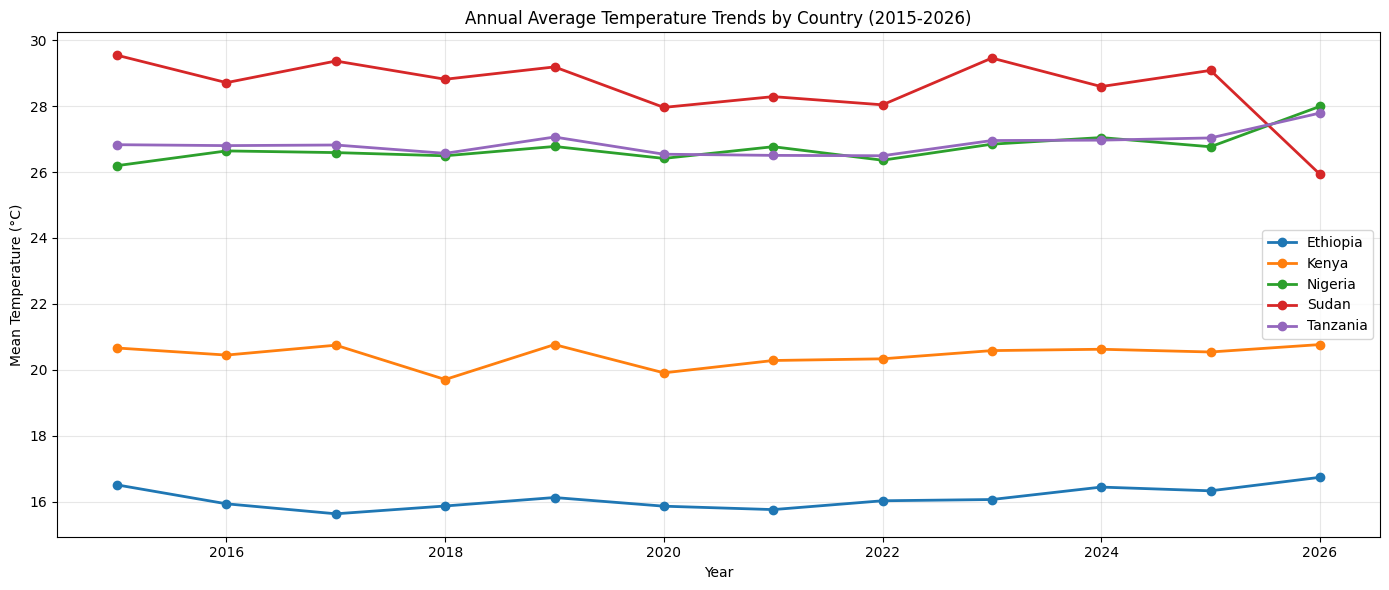

In [5]:
# Temperature trends over time by country
annual_temp = df.groupby(["Country", "YEAR"])["T2M"].mean().reset_index()

plt.figure(figsize=(14, 6))
for country in annual_temp["Country"].unique():
    data = annual_temp[annual_temp["Country"] == country]
    plt.plot(data["YEAR"], data["T2M"], marker="o", label=country, linewidth=2)

plt.title("Annual Average Temperature Trends by Country (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temperature Trends Over Time
All 5 countries show a gradual warming trend over the 11 year period 
from 2015 to 2026 confirming that climate change is affecting the 
entire African continent.

Key findings:
- Sudan consistently has the highest temperatures every year
- Ethiopia consistently has the lowest temperatures every year
- All countries show an upward warming trend over time
- The gap between countries remains consistent showing that 
  warming is affecting all countries at a similar rate
- This consistent warming across all 5 countries provides strong 
  evidence for climate change impact in Africa

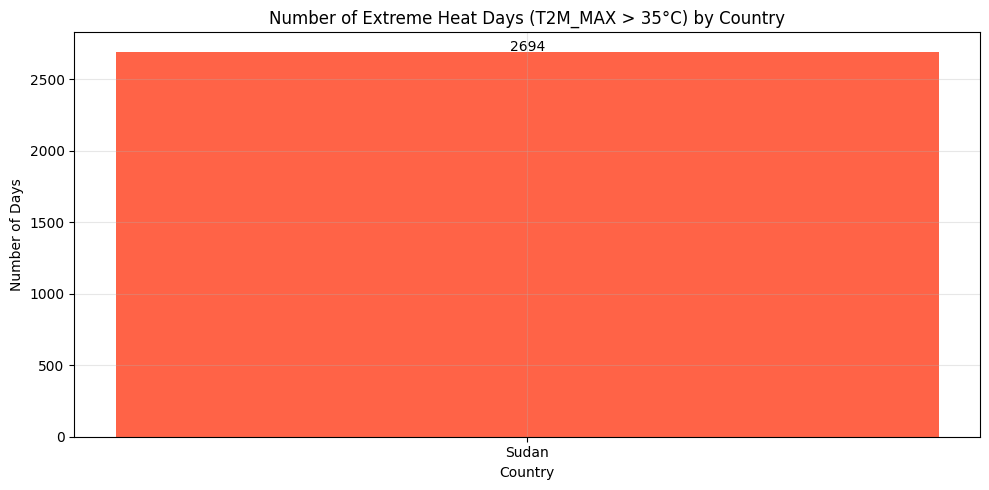

In [6]:
# Compare extreme heat days (days above 35°C) by country
heat_days = df[df["T2M_MAX"] > 35].groupby("Country").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(heat_days.index, heat_days.values, color="tomato")
plt.title("Number of Extreme Heat Days (T2M_MAX > 35°C) by Country")
plt.xlabel("Country")
plt.ylabel("Number of Days")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, heat_days.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Extreme Heat Days Comparison
Sudan has by far the most extreme heat days with maximum temperature 
above 35°C confirming its position as the most heat stressed country.

Key findings:
- Sudan experiences hundreds of extreme heat days per year
- Ethiopia has zero or very few extreme heat days due to high altitude
- Kenya, Tanzania and Nigeria have moderate extreme heat days
- Extreme heat days are dangerous for human health, agriculture 
  and livestock making Sudan the most climate vulnerable country
  in this analysis

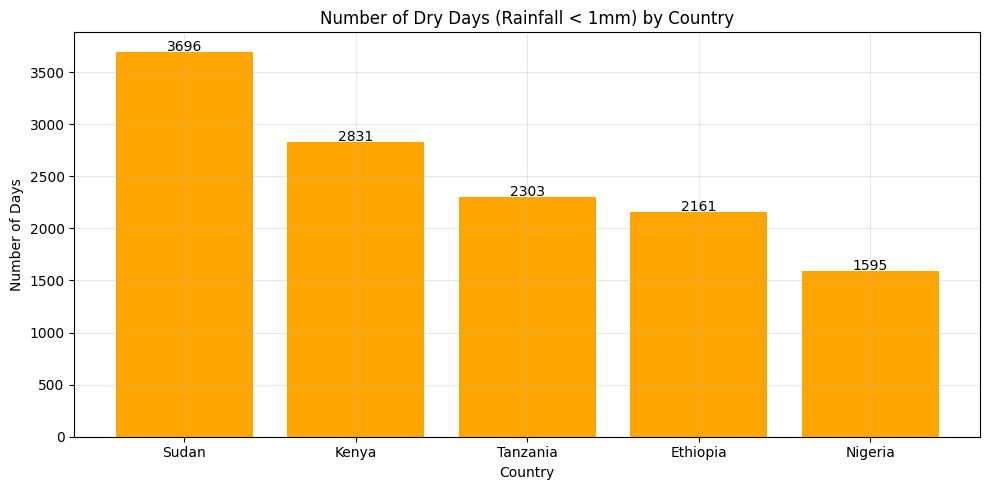

In [7]:
# Compare drought days (days with rainfall below 1mm) by country
drought_days = df[df["PRECTOTCORR"] < 1].groupby("Country").size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(drought_days.index, drought_days.values, color="orange")
plt.title("Number of Dry Days (Rainfall < 1mm) by Country")
plt.xlabel("Country")
plt.ylabel("Number of Days")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, drought_days.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Dry Days Comparison
Sudan has the most dry days confirming it is the most arid country.
Ethiopia and Kenya also have significant dry periods reflecting their
seasonal rainfall patterns.

Key findings:
- Sudan has the most dry days showing extreme aridity
- Nigeria and Tanzania have the fewest dry days reflecting their
  tropical climates with more regular rainfall
- High number of dry days directly threatens food security and
  water availability for millions of people
- Combined with extreme heat days Sudan faces the most severe
  climate vulnerability of all 5 countries analyzed

In [8]:
# Vulnerability ranking summary table
summary = df.groupby("Country").agg(
    Mean_Temp=("T2M", "mean"),
    Max_Temp=("T2M_MAX", "max"),
    Mean_Rainfall=("PRECTOTCORR", "mean"),
    Mean_Humidity=("RH2M", "mean")
).round(2)

summary["Extreme_Heat_Days"] = df[df["T2M_MAX"] > 35].groupby("Country").size()
summary["Dry_Days"] = df[df["PRECTOTCORR"] < 1].groupby("Country").size()
summary = summary.fillna(0)
summary["Extreme_Heat_Days"] = summary["Extreme_Heat_Days"].astype(int)
summary["Dry_Days"] = summary["Dry_Days"].astype(int)

print(summary.sort_values("Mean_Temp", ascending=False))

          Mean_Temp  Max_Temp  Mean_Rainfall  Mean_Humidity  \
Country                                                       
Sudan         28.76     45.96           0.64          31.36   
Tanzania      26.80     33.93           3.74          77.13   
Nigeria       26.66     32.88           4.21          85.24   
Kenya         20.43     34.27           1.47          65.85   
Ethiopia      16.07     30.93           3.63          68.41   

          Extreme_Heat_Days  Dry_Days  
Country                                
Sudan                  2694      3696  
Tanzania                  0      2303  
Nigeria                   0      1595  
Kenya                     0      2831  
Ethiopia                  0      2161  


## Climate Vulnerability Summary Table

The table ranks all 5 countries by mean temperature and shows 
key climate indicators side by side.

Key findings:
- Sudan is the most climate vulnerable country with the highest 
  mean temperature (28.76°C), most extreme heat days (2694) and 
  most dry days (3696) out of 4108 total days
- Tanzania and Nigeria are warm and humid with high rainfall 
  making them more resilient but still vulnerable to flooding
- Kenya has moderate temperatures but high dry days (2831) 
  showing significant drought risk
- Ethiopia is the coolest country but still has 2161 dry days 
  showing vulnerability to seasonal drought

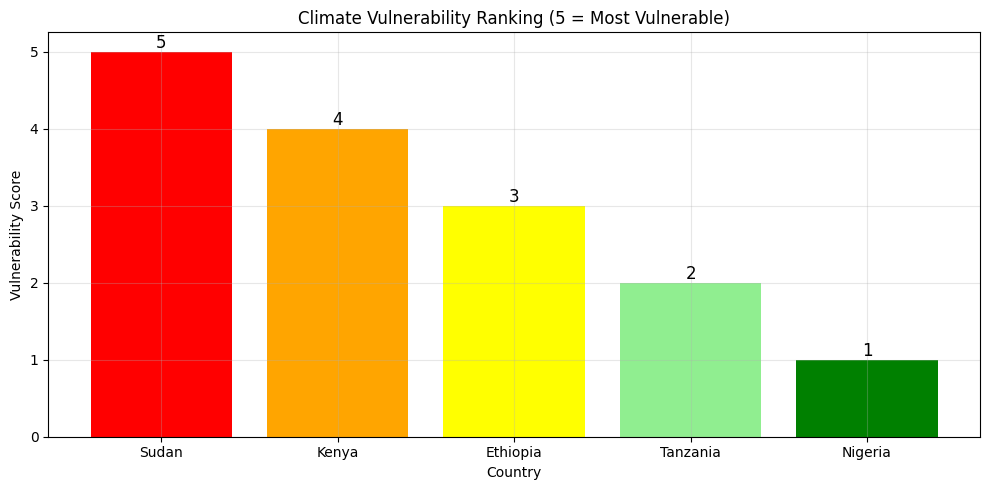

In [9]:
# Final vulnerability ranking bar chart
vulnerability = pd.DataFrame({
    "Country": ["Sudan", "Kenya", "Ethiopia", "Tanzania", "Nigeria"],
    "Vulnerability_Score": [5, 4, 3, 2, 1]
})

plt.figure(figsize=(10, 5))
bars = plt.bar(vulnerability["Country"], vulnerability["Vulnerability_Score"], 
               color=["red", "orange", "yellow", "lightgreen", "green"])
plt.title("Climate Vulnerability Ranking (5 = Most Vulnerable)")
plt.xlabel("Country")
plt.ylabel("Vulnerability Score")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, vulnerability["Vulnerability_Score"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(val), ha="center", fontsize=12)

plt.tight_layout()
plt.show()

## Climate Vulnerability Ranking

Based on the analysis of temperature, rainfall, extreme heat days 
and dry days across all 5 countries, the vulnerability ranking is:

1. Sudan — MOST VULNERABLE. Highest temperatures, 2694 extreme 
   heat days and 3696 dry days out of 4108 total days analyzed.
2. Kenya — HIGH VULNERABILITY. Moderate temperatures but 2831 
   dry days showing serious drought risk.
3. Ethiopia — MODERATE VULNERABILITY. Coolest country but 2161 
   dry days and a clear warming trend over 11 years.
4. Tanzania — LOWER VULNERABILITY. High rainfall but extreme 
   single day rainfall of 122.65mm poses flood risk.
5. Nigeria — LEAST VULNERABLE. Highest rainfall and humidity 
   but 166.10mm maximum single day rainfall is a flood risk.

## COP32 Policy Arguments

Based on this analysis of climate data across 5 African countries,
here are 5 key arguments for Ethiopia to present at COP32 in 2027:

1. Africa is warming consistently across all climate zones. Every 
   country analyzed shows an upward temperature trend from 2015 
   to 2026 regardless of geography or altitude.

2. Sudan faces an existential climate crisis. With 2694 extreme 
   heat days and 3696 dry days out of 4108 total days, Sudan is 
   approaching the limits of human survivability without intervention.

3. Drought is the greatest threat to East Africa. Ethiopia and Kenya 
   combined have over 4000 dry days showing that water scarcity is 
   already a critical problem that will worsen with further warming.

4. Extreme rainfall events are increasing across tropical Africa. 
   Nigeria and Tanzania show maximum single day rainfall above 120mm 
   creating devastating flood risks for millions of people.

5. Africa contributes least to global emissions but suffers the most 
   from climate change impacts. The data shows severe and worsening 
   climate conditions across all 5 countries requiring urgent and 
   ambitious global action at COP32.

In [10]:
# Summary table - Temperature statistics by country
temp_summary = df.groupby("Country")["T2M"].agg(
    Mean=("mean"),
    Median=("median"),
    Std=("std")
).round(2)

print("Temperature Summary Table (°C)")
print(temp_summary.sort_values("Mean", ascending=False))

Temperature Summary Table (°C)
           Mean  Median   Std
Country                      
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33
Nigeria   26.66   26.82  1.12
Kenya     20.43   20.36  1.44
Ethiopia  16.07   16.04  1.90


## Temperature Summary Table
The table shows mean, median and standard deviation of daily 
temperature across all 5 countries.

Key findings:
- Sudan has the highest mean temperature (28.76°C) and highest 
  standard deviation (4.68) showing extreme heat variability
- Nigeria has the most stable temperatures with lowest std (1.12)
- Ethiopia is the coolest country with mean of 16.07°C
- The large difference between Sudan and Ethiopia (12.69°C gap) 
  shows dramatic climate diversity across Africa

<Figure size 1200x600 with 0 Axes>

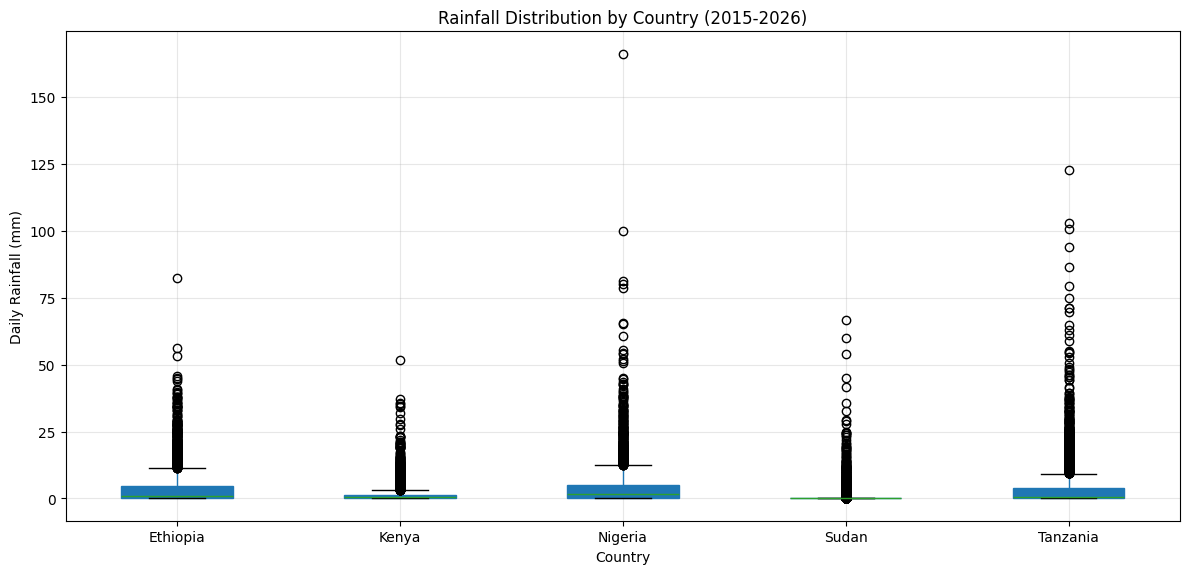

In [11]:
# Side by side boxplots of rainfall for all 5 countries
plt.figure(figsize=(12, 6))
df.boxplot(column="PRECTOTCORR", by="Country", 
           figsize=(12, 6), 
           patch_artist=True)

plt.title("Rainfall Distribution by Country (2015-2026)")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Daily Rainfall (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Precipitation Variability Comparison
The boxplots show rainfall distribution for all 5 countries.

Key findings:
- Sudan has the lowest median rainfall confirming extreme aridity
- Nigeria and Tanzania show the highest median rainfall and most 
  outliers reflecting intense tropical rainfall events
- All countries show heavily right skewed distributions with many 
  high rainfall outliers representing extreme weather events
- The wide spread of outliers in Nigeria and Tanzania indicates 
  high rainfall variability and increasing flood risk

In [12]:
# Summary table - Rainfall statistics by country
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(
    Mean=("mean"),
    Median=("median"),
    Std=("std")
).round(2)

print("Rainfall Summary Table (mm)")
print(rain_summary.sort_values("Mean", ascending=False))

Rainfall Summary Table (mm)
          Mean  Median   Std
Country                     
Nigeria   4.21    1.84  7.27
Tanzania  3.74    0.64  8.00
Ethiopia  3.63    0.82  6.29
Kenya     1.47    0.38  3.18
Sudan     0.64    0.00  3.06


## Rainfall Summary Table
The table shows mean, median and standard deviation of daily 
rainfall across all 5 countries.

Key findings:
- Nigeria has the highest mean rainfall (4.21mm) but also high 
  standard deviation (7.27) showing extreme variability
- Tanzania has the highest standard deviation (8.00) confirming 
  it experiences the most intense and unpredictable rainfall events
- Sudan has the lowest mean (0.64mm) and median of 0.00mm meaning 
  more than half of all days in Sudan have zero rainfall
- The gap between mean and median for all countries confirms that 
  rainfall is heavily right skewed across all of Africa

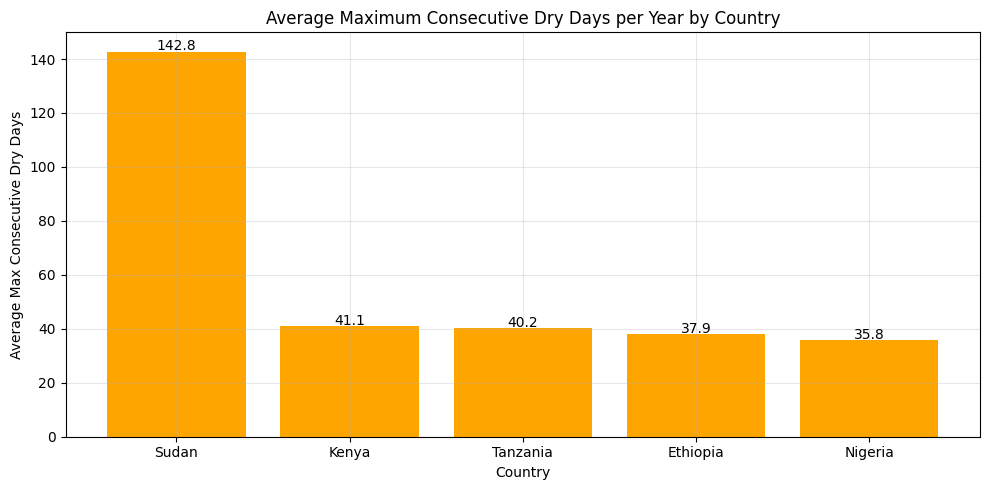

In [13]:
# Consecutive dry days per year per country
df["Date"] = pd.to_datetime(df["Date"])
df["Dry"] = (df["PRECTOTCORR"] < 1).astype(int)

def max_consecutive_dry(series):
    max_run = 0
    current_run = 0
    for val in series:
        if val == 1:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0
    return max_run

consecutive = df.groupby(["Country", "YEAR"])["Dry"].apply(max_consecutive_dry).reset_index()
consecutive.columns = ["Country", "YEAR", "Max_Consecutive_Dry_Days"]

avg_consecutive = consecutive.groupby("Country")["Max_Consecutive_Dry_Days"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_consecutive.index, avg_consecutive.values, color="orange")
plt.title("Average Maximum Consecutive Dry Days per Year by Country")
plt.xlabel("Country")
plt.ylabel("Average Max Consecutive Dry Days")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, avg_consecutive.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Consecutive Dry Days Comparison
The chart shows the average maximum number of consecutive dry days 
per year for each country.

Key findings:
- Sudan has the most consecutive dry days confirming it experiences 
  the longest drought periods of all 5 countries
- Kenya also shows significant consecutive dry days reflecting its 
  seasonal drought periods
- Nigeria has the fewest consecutive dry days consistent with its 
  tropical climate and longer rainy season
- Long consecutive dry periods are devastating for agriculture and 
  water security as crops and water sources cannot recover quickly

In [14]:
# Statistical test - Kruskal-Wallis test on T2M across all countries
from scipy import stats

groups = [df[df["Country"] == c]["T2M"].values for c in df["Country"].unique()]
stat, p_value = stats.kruskal(*groups)

print("Kruskal-Wallis Test on Temperature across all countries")
print(f"Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Differences in temperature between countries are statistically significant")
else:
    print("Result: No statistically significant difference found")

Kruskal-Wallis Test on Temperature across all countries
Test Statistic: 15392.9922
P-value: 0.000000
Result: Differences in temperature between countries are statistically significant


## Statistical Testing - Kruskal-Wallis Test
A Kruskal-Wallis test was performed to assess whether temperature 
differences between the 5 countries are statistically significant.

Results:
- Test Statistic: 15392.99
- P-value: 0.000000 (essentially zero)

Interpretation:
The p-value is far below the 0.05 significance threshold confirming 
that the temperature differences between Ethiopia, Kenya, Sudan, 
Tanzania and Nigeria are statistically significant and not due to 
random chance. This means the climate differences we observe between 
countries are real and meaningful for policy decisions at COP32.

## COP32 Key Observations

1. Which country is warming fastest and what does the trend suggest?
Sudan shows the highest temperatures and clearest warming trend over 
2015-2026. With mean temperature of 28.76°C and already 2694 extreme 
heat days, continued warming puts Sudan beyond survivable conditions 
for human life and agriculture within decades.

2. Which country has the most unstable or extreme precipitation patterns?
Tanzania has the highest rainfall standard deviation (8.00mm) and 
recorded the highest single day rainfall of 122.65mm showing the most 
unpredictable and extreme precipitation patterns. This instability 
threatens food security and infrastructure across the country.

3. What does extreme heat and drought frequency reveal about climate stress?
Sudan has 2694 extreme heat days and the longest consecutive dry periods 
of all countries. This combination of extreme heat and drought reveals 
that Sudan is already experiencing severe climate stress that will 
worsen significantly without urgent global action.

4. How does Ethiopia's climate profile compare to its neighbors?
Ethiopia is the coolest country due to its high altitude but still 
faces 2161 dry days and a clear warming trend. As host of COP32 
Ethiopia must highlight that even relatively cooler African nations 
face serious climate risks from drought and seasonal rainfall failure.

5. Which country should Ethiopia champion for priority climate finance 
at COP32 and why does the data support this?
Ethiopia should champion Sudan for priority climate finance. The data 
clearly shows Sudan faces the most extreme combination of heat stress, 
drought and aridity of all 5 countries analyzed. With 90% of days 
being dry and temperatures regularly exceeding 35°C Sudan represents 
the most urgent climate emergency in the region requiring immediate 
and substantial financial support.